In [7]:
%pip --quiet install git+https://github.com/mfinzi/equivariant-MLP.git

In [8]:
from emlp.nn import EMLP, EMLPBlock, Linear, BiLinear, GatedNonlinearity, uniform_rep
from emlp.groups import SO#,O,S,Z, SO13p, SO13, O13
from emlp.reps import vis, V, Scalar
from emlp.datasets import Inertia

import jax.numpy as jnp
import numpy as np
import objax
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from jax import vmap

import matplotlib.pyplot as plt

In [9]:
class InertiaModel:
    def __init__(self, name) :
        self.name=name
        self.trainset = Inertia(1000) # Initialize dataset with 1000 examples
        self.testset = Inertia(2000)
        self.opt = None
        self.model = None
        self.test_losses = []
        self.train_losses = []
        self.rep_in = None
        self.rep_out = None
        self.testloader = None
        self.trainloder = None
        self.NUM_EPOCHS = None

    
    def create_EMLP_model(self,rep_in, rep_out, group, num_layers=3 ,ch=384):
        self.model = EMLP(rep_in, rep_out, group, num_layers=num_layers, ch=ch)
        self.opt = objax.optimizer.Adam(self.model.vars())
        self.rep_in = rep_in
        self.rep_out = rep_out
        
        
   # @objax.Jit
   # @objax.Function.with_vars(self.model.vars())
    def loss(self,x, y):
        yhat = self.model(x)
        return ((yhat-y)**2).mean()
    
  #  @objax.Jit
  #  @objax.Function.with_vars(self.model.vars()+self.opt.vars())
    def train_op(self,x, y, lr):
        grad_and_val = objax.GradValues(self.loss, self.model.vars())
        g, v = grad_and_val(x, y)
        self.opt(lr=lr, grads=g)
        return v
    
    def train_model(self,BS=500, lr=3e-3, NUM_EPOCHS=500):
        self.trainloader = DataLoader(self.trainset,batch_size=BS,shuffle=True)
        self.testloader = DataLoader(self.testset,batch_size=BS,shuffle=True)
        
        jit_loss = objax.Jit(self.loss, self.model.vars())
        jit_train = objax.Jit(self.train_op, self.model.vars()+self.opt.vars())

        self.NUM_EPOCHS=NUM_EPOCHS
        
        for epoch in tqdm(range(NUM_EPOCHS)):
            self.train_losses.append(np.mean([jit_train(jnp.array(x),jnp.array(y),lr) for (x,y) in self.trainloader]))
            if not epoch%10:
                self.test_losses.append(np.mean([jit_loss(jnp.array(x),jnp.array(y)) for (x,y) in self.testloader]))
    
    def plot_losses(self):
        plt.plot(np.arange(self.NUM_EPOCHS),self.train_losses,label='Train loss')
        plt.plot(np.arange(0,self.NUM_EPOCHS,10),self.test_losses,label='Test loss')
        plt.legend()
        plt.title(self.name)
        plt.yscale('log')
        
    def rel_err(a,b):
        return jnp.sqrt(((a-b)**2).mean())/(jnp.sqrt((a**2).mean())+jnp.sqrt((b**2).mean()))

    def equivariance_err(self,mb):
        x,y = mb
        x,y= jnp.array(x),jnp.array(y)
        gs = G.samples(x.shape[0])
        rho_gin = vmap(self.rep_in.rho_dense)(gs)
        rho_gout = vmap(self.rep_out.rho_dense)(gs)
        y1 = model((rho_gin@x[...,None])[...,0],training=False)
        y2 = (rho_gout@model(x,training=False)[...,None])[...,0]
        return rel_err(y1,y2)
    
    def test_equivariance(self):
        print(f"Average test equivariance error {np.mean([self.equivariance_err(mb) for mb in self.testloader]):.2e}")

In [10]:
G = SO(3)
rep_in = 5*Scalar+5*V
rep_out = V*V

In [11]:
model1 = InertiaModel('Default model')
model1.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=384)
rep_hidden_uniform = uniform_rep(384,G)
print(rep_hidden_uniform)

102V⁰+34V+11V²+3V³


In [12]:
vis(rep_in(G),rep_hidden_uniform)

In [13]:
vis(rep_hidden_uniform,rep_out(G))

  0%|          | 0/500 [00:00<?, ?it/s]

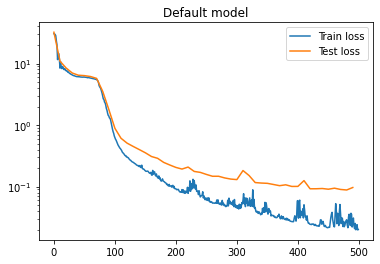

In [14]:
model1.train_model()
model1.plot_losses()

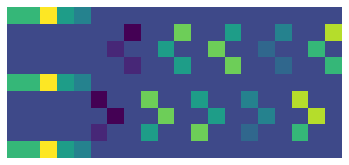

In [15]:
model2 = InertiaModel('No hidden layer')
model2.create_EMLP_model(rep_in,rep_out,group=G,num_layers=0)
vis(rep_in(G),rep_out(G))

  0%|          | 0/500 [00:00<?, ?it/s]

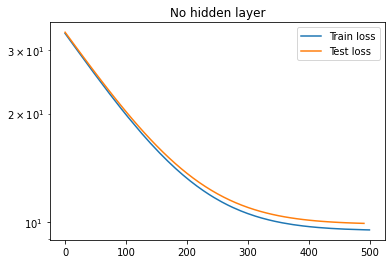

In [16]:
model2.train_model()
model2.plot_losses()

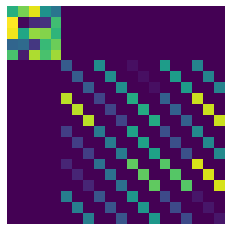

In [17]:
model3 = InertiaModel('Keep input rep in all hidden layers')
model3.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=rep_in)
vis(rep_in(G),rep_in(G))

  0%|          | 0/500 [00:00<?, ?it/s]

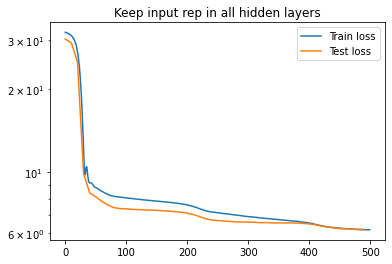

In [18]:
model3.train_model()
model3.plot_losses()

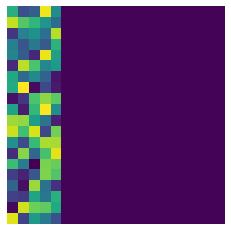

In [19]:
rep_scalar = 20*Scalar
vis(rep_in(G),rep_scalar(G))
model4 = InertiaModel('Only scalars in hidden layer')
model4.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=rep_scalar)

  0%|          | 0/500 [00:00<?, ?it/s]

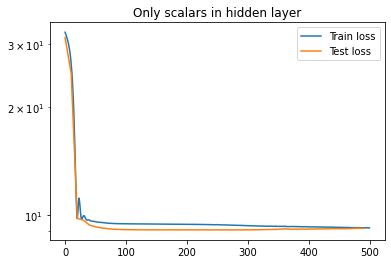

In [20]:
model4.train_model()
model4.plot_losses()

In [21]:
model5 = InertiaModel('Hidden dim = 1000')
model5.create_EMLP_model(rep_in,rep_out,group=G,num_layers=3,ch=1000)
print(uniform_rep(1000,G))
vis(rep_in(G),uniform_rep(1000,G))

Krylov Solving for Equivariant Subspace r<=10:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=20:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=40:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=80:   0%|          | 0/100 [00:00<?, ?it/s]

Krylov Solving for Equivariant Subspace r<=160:   0%|          | 0/100 [00:00<?, ?it/s]

217V⁰+72V+24V²+7V³+2V⁴


  0%|          | 0/500 [00:00<?, ?it/s]

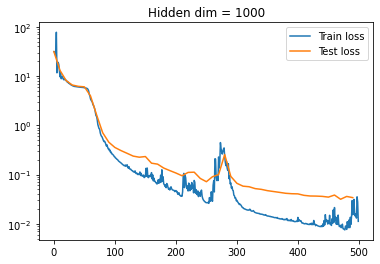

In [22]:
model5.train_model()
model5.plot_losses()

In [23]:
model6 = InertiaModel('6 hidden layers')
model6.create_EMLP_model(rep_in,rep_out,group=G,num_layers=6,ch=384)

  0%|          | 0/500 [00:00<?, ?it/s]

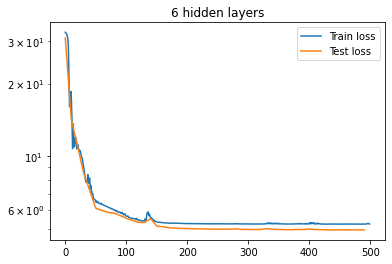

In [24]:
model6.train_model()
model6.plot_losses()